<a href="https://colab.research.google.com/github/Pubudu-98/Colab/blob/main/Atlas_lab_data_labeled_samples_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Analysis

In [ ]:
import pandas as pd

# Load the data from the text file using read_csv
# Assuming the file has one column and no header
# Display the first few rows

df = pd.read_csv('/content/data-sheet-1', header=None, names=['Status'])
display(df.head())

,Status
0,Prod V2 Verifications:
1,\t\t\t\t\t1. Rolling - Rejected
2,\t\t\t\t\t2. Rolling - Rejected
3,\t\t\t\t\t3. Rolling - Rejected
4,\t\t\t\t\t4. Standing up - Accepted


In [ ]:
# Categorize the data

df['Category'] = df['Status'].apply(lambda x: 'Accepted' if 'Accepted' in x else ('Rejected' if 'Rejected' in x else 'Other'))
display(df.head())

,Status,Category
0,Prod V2 Verifications:,Other
1,\t\t\t\t\t1. Rolling - Rejected,Rejected
2,\t\t\t\t\t2. Rolling - Rejected,Rejected
3,\t\t\t\t\t3. Rolling - Rejected,Rejected
4,\t\t\t\t\t4. Standing up - Accepted,Accepted


In [ ]:
# Perform EDA - Count categories

category_counts = df['Category'].value_counts()
display(category_counts)

,count
Category,
Accepted,38
Rejected,33
Other,3


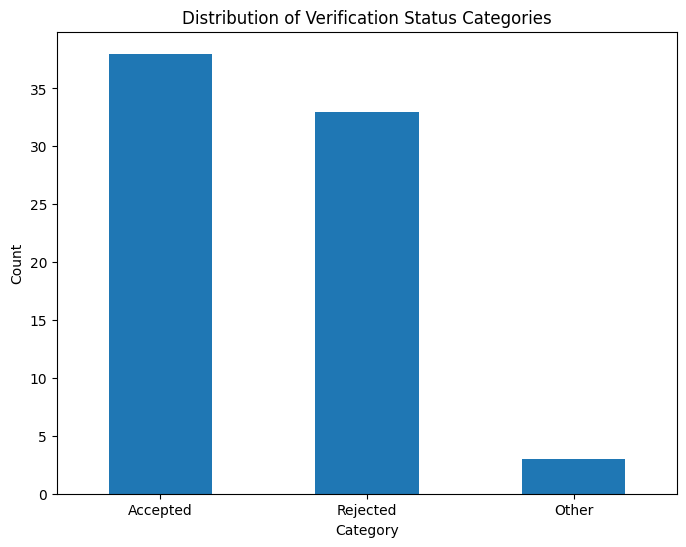

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar')
plt.title('Distribution of Verification Status Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

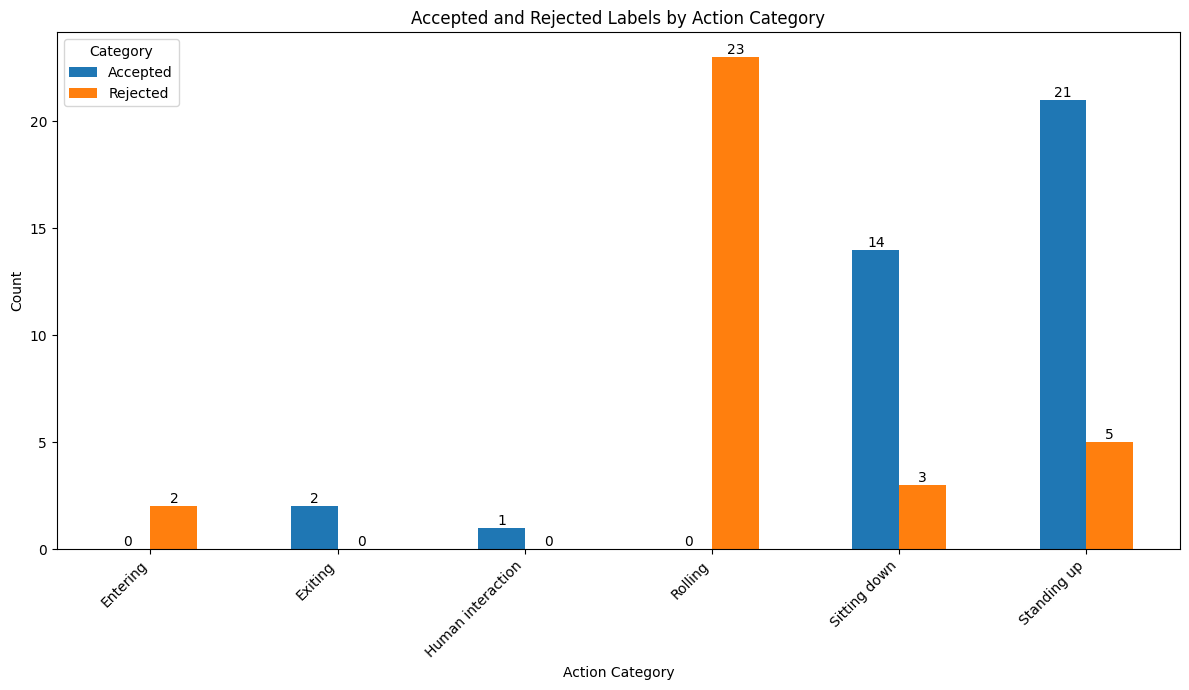

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the action category from the 'Status' column
# This is a simplified approach, adjust the regex if needed for variations in your data
df['Action'] = df['Status'].str.extract(r'\d+\.\s*(.*?)\s*-')

# Filter out rows where Action could not be extracted or is not relevant
df_filtered = df.dropna(subset=['Action'])
df_filtered = df_filtered[~df_filtered['Action'].str.contains('Prod V2 Verifications', na=False)]

# Create a crosstab to count Accepted/Rejected for each Action
action_category_counts = pd.crosstab(df_filtered['Action'], df_filtered['Category'])

# Plotting the grouped bar chart
ax = action_category_counts[['Accepted', 'Rejected']].plot(kind='bar', figsize=(12, 7))
plt.title('Accepted and Rejected Labels by Action Category')
plt.xlabel('Action Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add counts on top of the bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge')

plt.show()



In [ ]:
# Display the counts for each category
display("Counts per category:")
display(category_counts)

# Calculate and display the total count
total_count = df.shape[0]
display(f"\nTotal number of entries: {total_count}")

'Counts per category:'

,count
Category,
Accepted,38
Rejected,33
Other,3


'\nTotal number of entries: 74'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data from the new text file
df_new = pd.read_csv('/content/data-sheet-2.txt', header=None, names=['Status'])
display(df_new.head())

,Status
0,Prod V2 Verifications:
1,\t\t\t\t\t1. Standing - Rejected
2,\t\t\t\t\t2. Standing - Submitted (Pre-Verified)
3,\t\t\t\t\t3. Entering - Rejected
4,\t\t\t\t\t4. Sitting - Accepted


In [ ]:
# Categorize the new data
df_new['Category'] = df_new['Status'].apply(lambda x: 'Accepted' if 'Accepted' in x else ('Rejected' if 'Rejected' in x else 'Other'))
display(df_new.head())

,Status,Category
0,Prod V2 Verifications:,Other
1,\t\t\t\t\t1. Standing - Rejected,Rejected
2,\t\t\t\t\t2. Standing - Submitted (Pre-Verified),Other
3,\t\t\t\t\t3. Entering - Rejected,Rejected
4,\t\t\t\t\t4. Sitting - Accepted,Accepted


In [ ]:
# Perform EDA - Count categories for the new data
category_counts_new = df_new['Category'].value_counts()
display(category_counts_new)

,count
Category,
Accepted,37
Rejected,34
Other,5


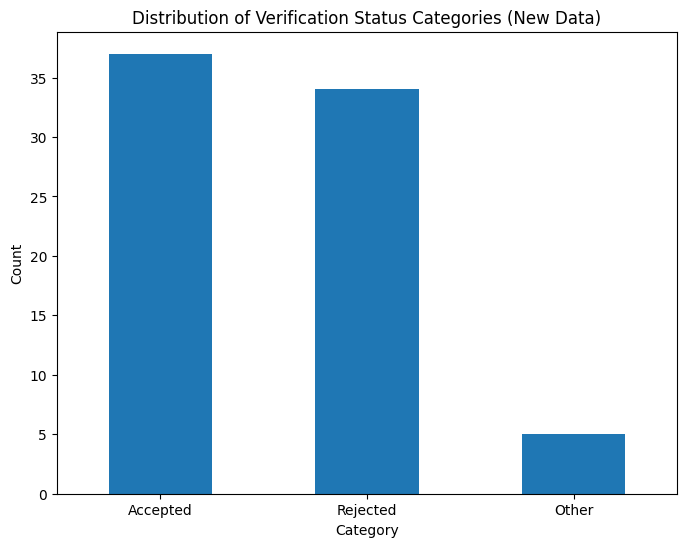

In [ ]:
# Visualize the distribution of categories for the new data
plt.figure(figsize=(8, 6))
category_counts_new.plot(kind='bar')
plt.title('Distribution of Verification Status Categories (New Data)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

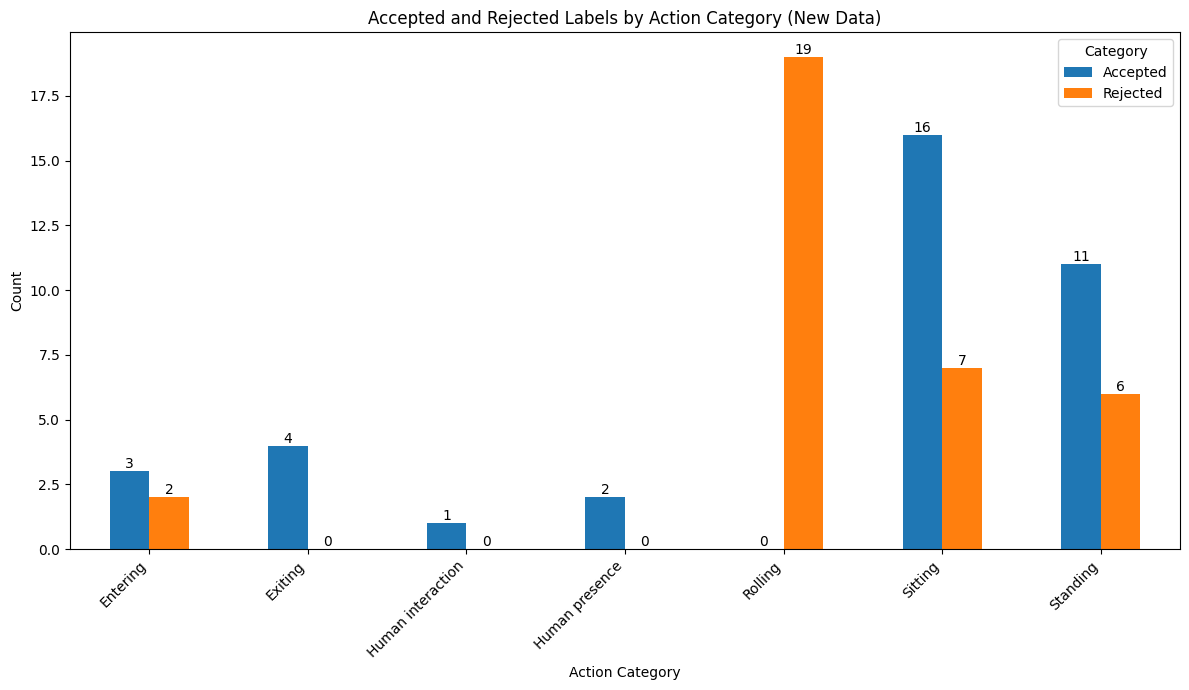

In [ ]:
# Extract the action category from the 'Status' column for the new data
df_new['Action'] = df_new['Status'].str.extract(r'\d+\.\s*(.*?)\s*-')

# Filter out rows where Action could not be extracted or is not relevant
df_filtered_new = df_new.dropna(subset=['Action'])
df_filtered_new = df_filtered_new[~df_filtered_new['Action'].str.contains('Prod V2 Verifications', na=False)]

# Create a crosstab to count Accepted/Rejected for each Action for the new data
action_category_counts_new = pd.crosstab(df_filtered_new['Action'], df_filtered_new['Category'])

# Plotting the grouped bar chart for the new data
ax_new = action_category_counts_new[['Accepted', 'Rejected']].plot(kind='bar', figsize=(12, 7))
plt.title('Accepted and Rejected Labels by Action Category (New Data)')
plt.xlabel('Action Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add counts on top of the bars
for container in ax_new.containers:
    ax_new.bar_label(container, label_type='edge')

plt.show()

In [ ]:
# Display the counts for each category in the new data
display("Counts per category (New Data):")
display(category_counts_new)

# Calculate and display the total count for the new data
total_count_new = df_new.shape[0]
display(f"\nTotal number of entries (New Data): {total_count_new}")

'Counts per category (New Data):'

,count
Category,
Accepted,37
Rejected,34
Other,5


'\nTotal number of entries (New Data): 76'